# Variational Autoencoder


##  Variational Autoencoder (VAE) — A Generative Approach

In this notebook, we explore **Variational Autoencoders (VAEs)** — a powerful class of generative models that combine **probabilistic reasoning** with **deep learning**.

###  What’s an Autoencoder Again?

A regular **Autoencoder** learns to compress input data into a low-dimensional vector (called the latent space), then reconstructs the original data from this compressed representation.

---

###  So What Makes VAEs Special?

VAEs take things a step further:

>  Instead of encoding each input into a single point in latent space, a VAE encodes it as a **distribution** (typically Gaussian).

That means:

* Each image gets encoded as a **mean** and **variance**.
* We sample from this distribution to generate the latent vector.
* This makes the model **stochastic** and **generative** — we can **generate brand new data** by sampling from the learned latent space! 🎨

---

###  Why Use VAEs?

*  Learn structured latent representations.
*  Smooth and continuous latent space.
*  Can **generate** new images (unlike classic Autoencoders).
*  Excellent for unsupervised learning, anomaly detection, image synthesis, and more.

---

In this notebook, we’ll:

* Build a custom VAE from scratch using **TensorFlow/Keras**
* Visualize the latent space
* Compare reconstructions
* Generate **new digits** from noise!



## Setup

### Importing Libraries & Setting Up the Environment

We start by importing all the necessary libraries to build and visualize our **Variational Autoencoder (VAE)**:


####  Libraries used:

* **TensorFlow/Keras**: Our main deep learning framework.
* **Keras layers & models**: Used to build the encoder and decoder.
* **Keras backend (K)**: For low-level tensor ops and custom loss functions.
* **Matplotlib**: For plotting reconstructions and latent space visualizations.
* **NumPy / SciPy**: For numerical and statistical operations.

---

###  Reproducibility & Backend Settings


* **`K.clear_session()`**: Clears previous models from memory.
* **`np.random.seed(237)`**: Ensures results are reproducible.
* **`CUDA_VISIBLE_DEVICES='-1'`**: Forces TensorFlow to run on CPU 



In [1]:
import tensorflow as tf
from tensorflow import keras
from keras.datasets import mnist
from keras.utils import plot_model
from keras.layers import Input, Reshape, Conv2D, Conv2DTranspose, Flatten, Dense, Lambda
from keras.models import Model
from keras import metrics
from keras import backend as K 

import numpy as np
import pandas as pd
from scipy.stats import norm

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

K.clear_session()
np.random.seed(237)
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

2025-06-13 12:40:10.165381: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749818410.450466      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749818410.536231      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Dataset

### Loading the MNIST Dataset

We load the **MNIST handwritten digits dataset**, which is a standard benchmark for image-based generative models.

####  Dataset Overview:

* 60,000 training images
* 10,000 validation/test images
* Each image is **28x28 pixels**, grayscale, and labeled `0-9`

We'll use this data to train our Variational Autoencoder to learn meaningful latent representations and generate new digit samples.


In [2]:
# Load Dataset
(X_train, Y_train), (X_valid, Y_valid) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step



### Data Preprocessing — Normalize and Reshape


* **Normalization**: Pixel values are originally in the range `0–255`. We scale them to `0–1` by dividing by `255.0`. This improves model convergence during training.
* **Reshaping**: Keras expects image inputs with a shape of `(height, width, channels)`. So we reshape:

  * From `(28, 28)` to `(28, 28, 1)`
  * This extra dimension (`1`) indicates a **grayscale channel**

The dataset is now properly formatted and normalized — perfect for feeding into a convolutional VAE model

In [3]:
# Normalize and reshape
X_train = X_train.astype('float32') / 255.
X_train = X_train.reshape(-1,28,28,1)

X_valid = X_valid.astype('float32') / 255.
X_valid = X_valid.reshape(-1,28,28,1)

### Visualizing the MNIST Digits

Before we build the VAE, let’s take a quick look at some samples from the **validation set**:


####  Purpose:

* We randomly display the **first 20 digits** from `X_valid`.
* This helps confirm that the images are properly loaded, normalized, and reshaped.
* It also gives us a baseline to compare against **future reconstructions** from the VAE.

####  Observation:

Each digit is 28x28 pixels, shown in grayscale, and stripped of axis ticks for cleaner visualization.

This gives us a quick sanity check — everything looks good to move forward and start designing the **encoder network** 


(28, 28, 1)


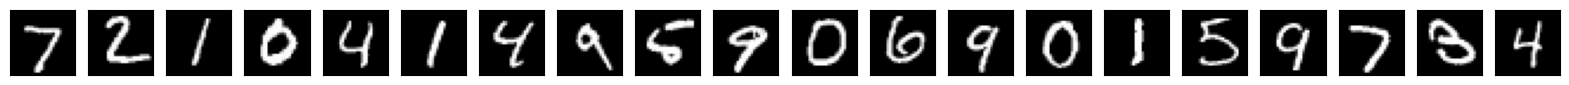

In [4]:
n = 20  # how many digits we will display
plt.figure(figsize=(20, 2))
print(X_valid[0].shape)
for i in range(n):
    # display original
    ax = plt.subplot(2, n, i + 1)
    plt.gray()
    plt.imshow(X_valid[i].reshape(28,28))
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

## Encoder

###  Reminder: What’s an Encoder in VAE?

In a Variational Autoencoder:

* The **encoder** takes an image and **compresses it** into a **latent vector** (a smaller set of numbers that represents the image).
* This is where we get two things:

  * **Mean vector** `z_mu`
  * **Log-variance vector** `z_log_sigma`
* These two are used to **sample the latent vector** for generating images.

---

### Encoder Architecture:

```python
input_img = Input(shape=img_shape)
```

You define the **input layer** — it expects a 28×28 grayscale image.

---

#### Convolution Layers:

```python
x = Conv2D(32, 3, padding='same', activation='relu')(input_img)
```

* Applies **32 filters** (small detectors) of size 3×3
* Keeps image size the same using `'same'` padding
* Adds ReLU activation

```python
x = Conv2D(64, 3, padding='same', activation='relu', strides=(2, 2))(x)
```

* Now we use **64 filters**
* `strides=(2, 2)` → This **shrinks the image** by half (from 28x28 → 14x14)

```python
x = Conv2D(64, 3, padding='same', activation='relu')(x)
```

* Another layer with 64 filters, more feature extraction

---

```python
shape_before_flattening = x.shape
```

 This is **important**! Before flattening the image into a 1D array, the shape should be stored.
This is needed later in the **decoder** to reshape it back.

---

```python
x = Flatten()(x)
```

* Converts the 3D feature map (like 14×14×64) into a 1D vector

```python
x = Dense(32, activation='relu')(x)
```

* Fully connected layer with 32 neurons — mixes features before the latent output

---

###  Latent Space Outputs:

```python
z_mu = Dense(latent_dim)(x)
z_log_sigma = Dense(latent_dim)(x)
```

  * `z_mu`: The **mean** of the latent distribution
  * `z_log_sigma`: The **log of the variance**

In VAE, we don’t directly output the latent vector. Instead, we **learn a distribution** from which we will **sample**.

---

### Why use `z_mu` and `z_log_sigma`?

In a standard Autoencoder, the latent vector becomes the direct output.

But in a **Variational Autoencoder**, the model should:

* Learn a **distribution** in the latent space (not fixed points).
* Be able to **generate new data** by sampling from this distribution.

This makes the model **generative** — it can **create new images**!




In [5]:
img_shape = (28, 28, 1)    # for MNIST
batch_size = 256
latent_dim = 2  # Number of latent dimension parameters

# Encoder architecture: Input -> Conv2D*4 -> Flatten -> Dense
input_img = Input(shape=img_shape)

x = Conv2D(32, 3, padding='same', activation='relu')(input_img)
x = Conv2D(64, 3, padding='same', activation='relu', strides=(2, 2))(x)
# x = Conv2D(64, 3, padding='same', activation='relu')(x)
x = Conv2D(64, 3, padding='same', activation='relu')(x)

# need to know the shape of the network here for the decoder
shape_before_flattening = x.shape

x = Flatten()(x)
x = Dense(32, activation='relu')(x)

# Two outputs, latent mean and (log)variance
z_mu = Dense(latent_dim)(x)
z_log_sigma = Dense(latent_dim)(x)

2025-06-13 12:40:33.707808: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## Reparameterization

To **sample a vector `z`** from a **normal distribution** defined by:

* Mean = `z_mu`
* Standard deviation = `exp(z_log_sigma)`

This sampling is **stochastic** (random) and it’s what allows the VAE to learn a **smooth latent space** for generating new data.

---

Neural networks are trained using **gradient descent**, which needs the model to be **fully differentiable**.

 **Random sampling breaks that** — because you can't backpropagate through random operations.

So we use the **reparameterization trick**:

> Instead of sampling `z` directly, we sample `epsilon` (random noise), and **transform it** using `z_mu` and `z_log_sigma`.
> This keeps the operation differentiable.

---

```python
def sampling(args):
    z_mu, z_log_sigma = args
```

* You pass the two outputs from the encoder: **mean** and **log-variance**

```python
    epsilon = tf.random.normal(shape=(tf.shape(z_mu)[0], latent_dim), mean=0., stddev=1.)
```

* Generate a **random noise vector** from standard normal distribution (mean 0, stddev 1)
* Shape is same as `z_mu` → one noise vector per sample in the batch

```python
    return z_mu + tf.exp(z_log_sigma) * epsilon
```

* Transform the noise using the learned distribution:

  * `tf.exp(z_log_sigma)` → turns log(σ²) into actual standard deviation (σ)
  * You then shift the noise by `z_mu`, scale it by σ

This gives you a **sampled latent vector `z`** from the learned distribution.

---

### Sampling:

```python
z = Lambda(sampling, output_shape=(latent_dim,))([z_mu, z_log_sigma])
```

* Wrapping the sampling function in a **Keras Lambda layer**, so it works like a normal layer in your model
* This lets the latent vector `z` flow through the network during training


In [6]:
# sampling function
def sampling(args):
    z_mu, z_log_sigma = args
    epsilon = tf.random.normal(shape=(tf.shape(z_mu)[0], latent_dim), mean=0., stddev=1.)

    return z_mu + tf.exp(z_log_sigma) * epsilon

# sample vector from the latent distribution
z = Lambda(sampling, output_shape=(latent_dim,))([z_mu, z_log_sigma])


## What is the Decoder?

The **decoder** takes the **latent vector `z`** (a small, compressed representation) and tries to **reconstruct the original image** from it — basically, reverse the encoding process.

---


### Input to the decoder

```python
decoder_input = Input(z.shape[1:])
```

* The decoder takes the **sampled latent vector `z`** as input.
* `z.shape[1:]` means the shape of one latent vector (like `(2,)` if latent\_dim = 2).

---

### Dense Layer to Expand

```python
x = Dense(np.prod(shape_before_flattening[1:]), activation='relu')(decoder_input)
```

* You take the small latent vector and **expand it** back into a large number of neurons — just like the flattened size before you did `Flatten()` in the encoder.
* `np.prod(shape_before_flattening[1:])` = multiply height × width × channels to get total pixels/features before flattening.

---

### Reshape into 3D Tensor

```python
x = Reshape(shape_before_flattening[1:])(x)
```

* Now, reshape that 1D vector back into a 3D shape (e.g., 14×14×64) — same as the shape before flattening in the encoder.

---

### Upsampling using Conv2DTranspose

```python
x = Conv2DTranspose(32, 3, padding='same', activation='relu', strides=(2, 2))(x)
```

* `Conv2DTranspose` is like **reverse convolution** — it increases the image size.
* Since the encoder reduced the image with stride (2,2), the decoder **upsamples** it back (e.g., from 14×14 to 28×28).

---

### Final Layer to Get Reconstructed Image

```python
x = Conv2D(1, 3, padding='same', activation='sigmoid')(x)
```

* You use one filter (`1`) because MNIST images are grayscale.
* Use `sigmoid` to get pixel values between **0 and 1**, matching the original image.

---

### Build the Decoder Model

```python
decoder = Model(decoder_input, x)
```

* Now you wrap everything into a **Keras Model**:
  Input = `decoder_input` (latent vector)
  Output = `x` (reconstructed image)

---

### Apply Decoder to Latent Vector

```python
z_decoded = decoder(z)
```

* You pass the **sampled latent vector `z`** into the decoder to get `z_decoded`, which is the **reconstructed image**.



In [7]:
# decoder takes the latent distribution sample as input
decoder_input = Input(z.shape[1:])

# Expand to 784 total pixels
x = Dense(np.prod(shape_before_flattening[1:]), activation='relu')(decoder_input)

# reshape
x = Reshape(shape_before_flattening[1:])(x)

# use Conv2DTranspose to reverse the conv layers from the encoder
x = Conv2DTranspose(32, 3, padding='same', activation='relu', strides=(2, 2))(x)
x = Conv2D(1, 3, padding='same', activation='sigmoid')(x)

# decoder model statement
decoder = Model(decoder_input, x)

# apply the decoder to the sample from the latent distribution
z_decoded = decoder(z)


## Why a Custom Layer?

In a VAE, we need to compute a **custom loss** that combines:

1. **Reconstruction loss** (how good is the output image?)
2. **KL Divergence loss** (how close is the latent space to a normal distribution?)

But since Keras models usually compute loss using `model.compile(loss=...)`, and our VAE needs a **loss that involves multiple variables**, we use a **custom layer** to calculate and register the loss manually.

---


### Define the Custom Layer Class

```python
class CustomVariationalLayer(keras.layers.Layer):
```

A new Keras layer where **loss is manually added** during training.

---

### Loss Function Inside the Layer

```python
def vae_loss(self, x, z_decoded, z_mu, z_log_sigma):
```

This function computes the **total VAE loss**. Inputs are:

* `x`: original input image
* `z_decoded`: output from the decoder
* `z_mu`, `z_log_sigma`: encoder outputs for latent mean and log-variance

---

#### Flatten Inputs

```python
x = tf.reshape(x, [tf.shape(x)[0], -1])
z_decoded = tf.reshape(z_decoded, [tf.shape(z_decoded)[0], -1])
```

* We flatten the images from 28×28 to 784 pixels for comparison.
* Batch size is preserved (`tf.shape(x)[0]`), the rest is flattened.

---

#### Reconstruction Loss

```python
xent_loss = keras.losses.binary_crossentropy(x, z_decoded)
```

* This is the **reconstruction loss**.
* It tells how close the output image is to the original image, pixel by pixel.
* `binary_crossentropy` is used since MNIST pixel values are between 0 and 1.

---

#### KL Divergence Loss

```python
kl_loss = -5e-4 * tf.reduce_mean(
    1 + z_log_sigma - tf.square(z_mu) - tf.exp(z_log_sigma), axis=-1
)
```

This is the **KL Divergence**, a regularization term that makes the learned latent space close to a standard normal distribution (mean=0, std=1).

The formula is:

$$
\text{KL} = -\frac{1}{2} \sum (1 + \log(\sigma^2) - \mu^2 - \sigma^2)
$$

* You're scaling it with `-5e-4` to balance it with the reconstruction loss.
* The `reduce_mean` calculates the average over the batch.

---

#### Total Loss

```python
return tf.reduce_mean(xent_loss + kl_loss)
```

Combines both losses and returns the total loss to be minimized.

---

### `call()` Method (Main Forward Function)

```python
def call(self, inputs):
    x, z_decoded, z_mu, z_log_sigma = inputs
    loss = self.vae_loss(x, z_decoded, z_mu, z_log_sigma)
    self.add_loss(loss)
    return x
```

* This method is called when the model runs.
* It calculates the custom loss and **adds it to the model's total loss** using `self.add_loss(...)`.
* It returns `x` (just to keep Keras happy — it expects a return value).

---

### Applying the Custom Loss Layer

```python
y = CustomVariationalLayer()([input_img, z_decoded, z_mu, z_log_sigma])
```

* You apply your custom loss layer to all the necessary inputs.
* This step doesn't change the output image — it just injects the **loss into the computation graph**.


In [8]:
class CustomVariationalLayer(keras.layers.Layer):

    def vae_loss(self, x, z_decoded, z_mu, z_log_sigma):
        x = tf.reshape(x, [tf.shape(x)[0], -1])
        z_decoded = tf.reshape(z_decoded, [tf.shape(z_decoded)[0], -1])
        
        # Reconstruction loss
        xent_loss = keras.losses.binary_crossentropy(x, z_decoded)
        
        # KL divergence
        kl_loss = -5e-4 * tf.reduce_mean(
            1 + z_log_sigma - tf.square(z_mu) - tf.exp(z_log_sigma), axis=-1
        )
        return tf.reduce_mean(xent_loss + kl_loss)

    def call(self, inputs):
        x, z_decoded, z_mu, z_log_sigma = inputs
        loss = self.vae_loss(x, z_decoded, z_mu, z_log_sigma)
        self.add_loss(loss)
        return x


# apply the custom loss to the input images and the decoded latent distribution sample
y = CustomVariationalLayer()([input_img, z_decoded, z_mu, z_log_sigma])


##  VAE Assembly

---

### 1. Full Model Definition

```python
vae = Model(input_img, y)
```

* The full VAE model is defined, where:

  * The **input** is provided as `input_img` (i.e., the original MNIST image).
  * The **output** is returned by `y`, which is the result of the `CustomVariationalLayer`.
    This layer returns the input image `x`, while the loss is internally added to the model.
* Through this model, the entire pipeline — encoding, sampling, and decoding — is carried out, with the custom loss being tracked during training.

---

### 2. Compilation of the Model

```python
vae.compile(optimizer='rmsprop', loss=None)
```

* The model is compiled using the **RMSprop optimizer**.
* No explicit loss function is provided (`loss=None`), as the loss has already been added inside the custom layer via the `add_loss()` method.

---

### 3. Model Summary Display

```python
print(vae.summary())
```

* A summary of the model architecture is printed.
* This summary includes the names of layers, output shapes, and the number of trainable parameters.

---

### 4. Model Architecture Visualization

* A diagram of the model is generated and saved as `model.png`.
* The following options are enabled to enrich the diagram:

  * Tensor shapes are shown (`show_shapes=True`).
  * Data types are displayed (`show_dtype=True`).
  * Layer names are included (`show_layer_names=True`).
  * Nested models are expanded (`expand_nested=True`).
  * A DPI of 50 is used for moderate resolution.

>  To ensure this visualization works, the packages `pydot` and `graphviz` must be installed:

```bash
pip install pydot graphviz
```

---

###  Outcome

* A fully functional Variational Autoencoder (VAE) has been built.
* The model is capable of learning latent representations through unsupervised training and reconstructing images from compressed representations.

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 28, 28, 1)      │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 28, 28, 32)     │            320 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 14, 14, 64)     │         18,496 │ conv2d[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 14, 14, 64)     │         36,928 │ conv2d_1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten (Flatten)         │ (None, 12544)          │              0 │ conv2d_2[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 32)             │        401,440 │ flatten[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 2)              │             66 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_2 (Dense)           │ (None, 2)              │             66 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda (Lambda)           │ (None, 2)              │              0 │ dense_1[0][0],         │
│                           │                        │                │ dense_2[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ functional (Functional)   │ (None, 28, 28, 1)      │         56,385 │ lambda[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ custom_variational_layer  │ (None, 28, 28, 1)      │              0 │ input_layer[0][0],     │
│ (CustomVariationalLayer)  │                        │                │ functional[0][0],      │
│                           │                        │                │ dense_1[0][0],         │
│                           │                        │                │ dense_2[0][0]          │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 513,701 (1.96 MB)

 Trainable params: 513,701 (1.96 MB)

 Non-trainable params: 0 (0.00 B)

None


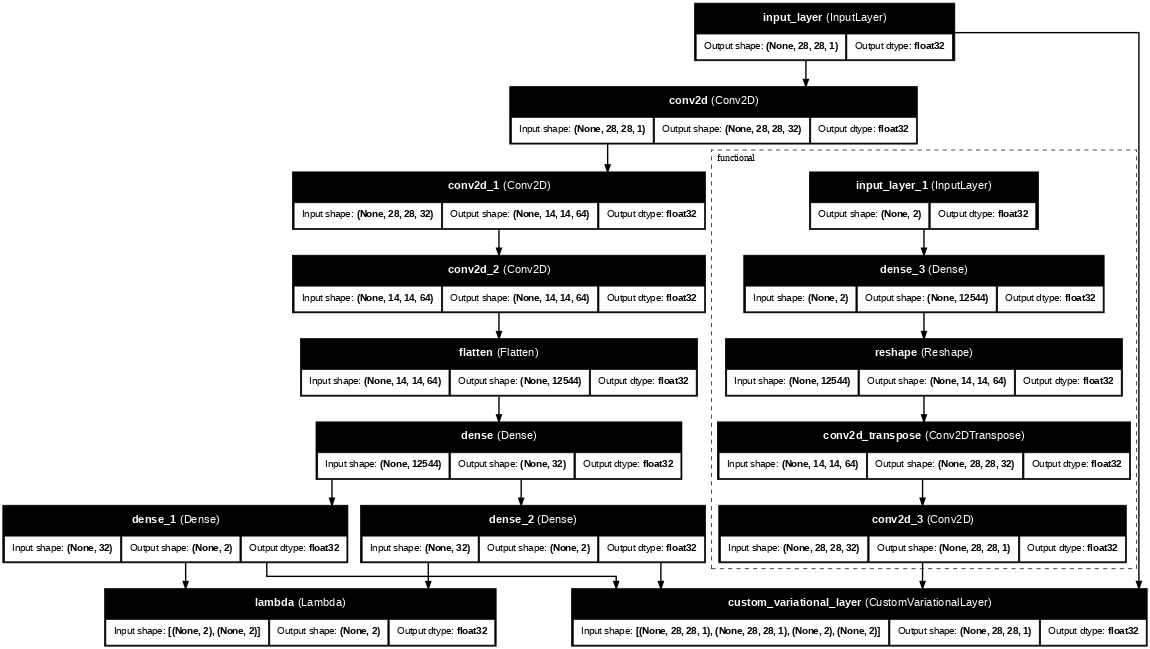

In [9]:
# VAE model statement
vae = Model(input_img, y)
vae.compile(optimizer='rmsprop', loss=None)
print(vae.summary())

plot_model(
    vae, 
    to_file='model.png', 
    show_shapes=True,
    show_dtype=True,
    show_layer_names=True,
    expand_nested=True,
    dpi=50,
)

* The variable `num_epochs` is assigned a value of 5.
* This value specifies that the model is to be trained for **five complete passes** over the training dataset.
* It is typically passed to the `.fit()` function during training, where the number of epochs determines how many times the model is updated using the entire training set.


In [10]:
num_epochs = 10

In [11]:
vae.fit(x=X_train, y=None, shuffle=True, epochs=num_epochs, batch_size=batch_size, validation_data=(X_valid, None))

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 115s 474ms/step - loss: 0.4336 - val_loss: 0.2434
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 138s 460ms/step - loss: 0.2359 - val_loss: 0.2180
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 106s 452ms/step - loss: 0.2162 - val_loss: 0.2105
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 107s 457ms/step - loss: 0.2091 - val_loss: 0.2063
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 107s 454ms/step - loss: 0.2053 - val_loss: 0.2039
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 108s 458ms/step - loss: 0.2031 - val_loss: 0.2025
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 107s 455ms/step - loss: 0.2012 - val_loss: 0.2002
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 106s 450ms/step - loss: 0.1997 - val_loss: 0.1992
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 105s 447ms/step - loss: 0.1985 - val_loss: 0.2005
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 106s 451ms/step - loss: 0.1968 - val_loss: 0.1987


## Latent Space

### Encoder Definition

```python
encoder = Model(input_img, z_mu)
```

* A model named `encoder` is defined using Keras’ functional API.
* The model is configured to take `input_img` as input and output `z_mu`, which represents the **mean vector** from the latent space.
* As a result, only the **encoder portion** of the full VAE is encapsulated by this model.

---

### Latent Space Encoding

```python
X_valid_encoded = encoder.predict(X_valid, batch_size=batch_size)
```

* The validation dataset `X_valid` is passed through the encoder.
* The corresponding **latent representations (z\_mu)** are predicted and stored in `X_valid_encoded`.
* The operation is carried out in batches, where the batch size is specified by the variable `batch_size`.

---

### Custom Color Map Setup

```python
custom_cmap = matplotlib.cm.get_cmap('brg')
custom_cmap.set_over('gray')
```

* A custom color map named `custom_cmap` is created using the `'brg'` color map from Matplotlib.
* An additional color, gray, is set for values **outside the range** of the colormap using `set_over()`.

---

### Latent Space Visualization

* A figure of size 16×8 inches is initialized.
* A gray circular marker (though the usage of `mpatches.Circle` seems incorrect here; it may need `plt.Circle` and to be added with `add_patch`).
* A legend is created with the gray marker labeled as `'Test'`.
* A 2D scatter plot is created using the first and second dimensions of the latent vectors in `X_valid_encoded`.

  * Points are colored based on the true labels stored in `Y_valid`.
  * The previously defined `custom_cmap` is applied.
* A color bar is displayed to indicate the label-to-color mapping.
* Finally, the plot is rendered using `plt.show()`.

---

>  **Note**:
> If `mpatches.Circle(4, radius=0.1, ...)` causes an error, it may need to be replaced with:

```python
gray_marker = mpatches.Patch(color='gray', label='Test')
```

40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step


/tmp/ipykernel_13/1973999133.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  custom_cmap = matplotlib.cm.get_cmap('brg')


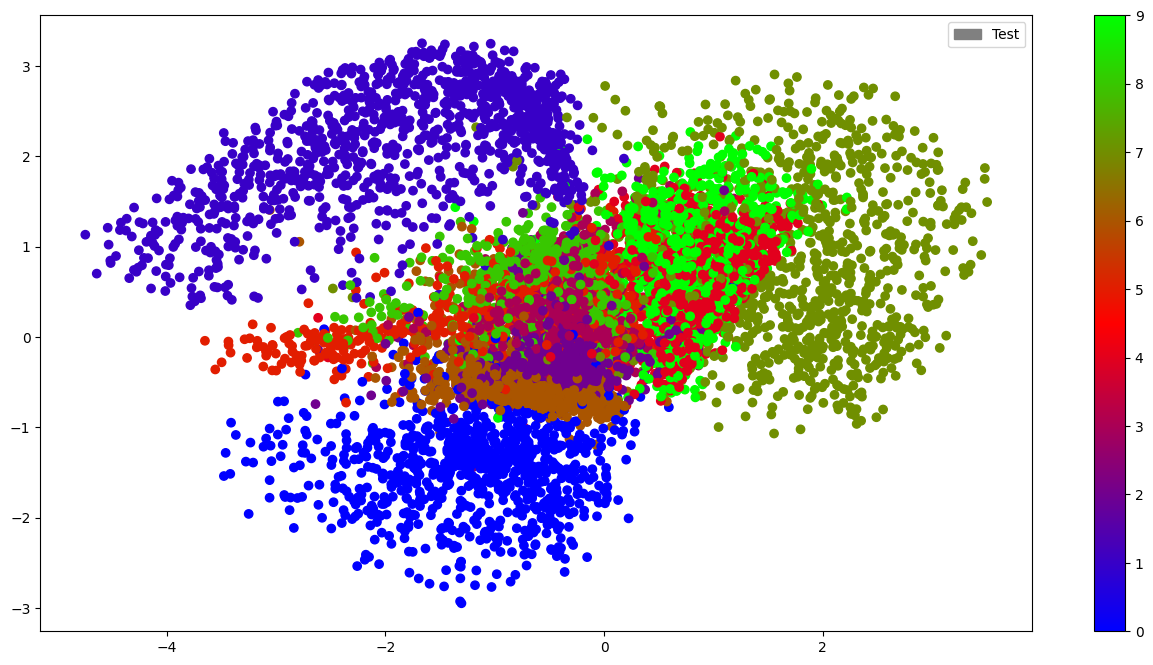

In [12]:
# Define encoder
encoder = Model(input_img, z_mu)

# Get encoded latent space
X_valid_encoded = encoder.predict(X_valid, batch_size=batch_size)

# Plotting
custom_cmap = matplotlib.cm.get_cmap('brg')
custom_cmap.set_over('gray')

plt.figure(figsize=(16, 8))
gray_marker = mpatches.Circle(4, radius=0.1, color='gray', label='Test')
plt.legend(handles=[gray_marker], loc='best')
plt.scatter(X_valid_encoded[:, 0], X_valid_encoded[:, 1], c=Y_valid, cmap=custom_cmap)
plt.colorbar()
plt.show()


###  Displaying a 2D Manifold of Digits 

---

#### Grid Setup

```python
n = 20
digit_size = 28
figure = np.zeros((digit_size * n, digit_size * n))
```

* A figure canvas of size `28×20` by `28×20` pixels is initialized using a NumPy array filled with zeros.
* This canvas is intended to display **400 generated digits** arranged in a `20×20` grid.
* Each digit is assumed to have dimensions of `28×28` pixels.

---

#### Latent Variable Grid Construction

```python
grid_x = norm.ppf(np.linspace(0.05, 0.95, n))
grid_y = norm.ppf(np.linspace(0.05, 0.95, n))
```

* Values from the **latent space** are chosen using the **percent-point function (inverse CDF)** of a standard normal distribution.
* This ensures that the sampled points span a range that covers most of the probability mass of the distribution.
* A 2D grid of latent points is constructed using `grid_x` and `grid_y`.

---

#### Image Generation via Decoder

```python
for i, yi in enumerate(grid_x):
    for j, xi in enumerate(grid_y):
        Z_sample = np.array([[xi, yi]])
        Z_sample = np.tile(Z_sample, batch_size).reshape(batch_size, 2)
        X_decoded = decoder.predict(Z_sample, batch_size=batch_size, verbose=0)
        digit = X_decoded[0].reshape(digit_size, digit_size)
        figure[i * digit_size: (i + 1) * digit_size,
               j * digit_size: (j + 1) * digit_size] = digit
```

* For each combination of `xi` and `yi` from the latent grid:

  * A 2D latent vector `Z_sample = [xi, yi]` is created.
  * This vector is **tiled to match the batch size** required by the decoder and reshaped accordingly.
  * The decoder model is then used to generate images from this latent vector.
  * From the batch of decoded images, the **first digit** is extracted and reshaped to `28×28`.
  * The digit is then placed in the corresponding position on the overall canvas.

---

#### Displaying the Generated Figure

```python
plt.figure(figsize=(10, 10))
plt.imshow(figure, cmap='gnuplot2')
plt.show()
```

* A new figure is initialized with a size of `10×10` inches.
* The composed `figure` canvas containing the generated digits is rendered using the `'gnuplot2'` colormap.
* Finally, the visualization is displayed using `plt.show().

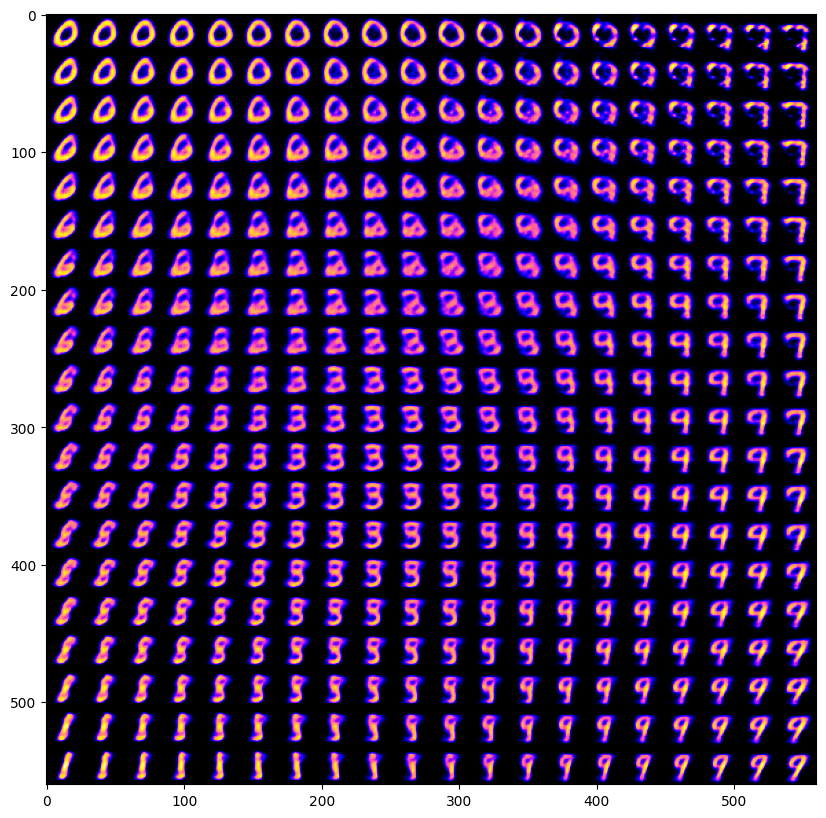

In [13]:
# Display a 2D manifold of the digits
n = 20  # figure with 20x20 digits
digit_size = 28
figure = np.zeros((digit_size * n, digit_size * n))

# Construct grid of latent variable values
grid_x = norm.ppf(np.linspace(0.05, 0.95, n))
grid_y = norm.ppf(np.linspace(0.05, 0.95, n))

# decode for each square in the grid
for i, yi in enumerate(grid_x):
    for j, xi in enumerate(grid_y):
        Z_sample = np.array([[xi, yi]])
        Z_sample = np.tile(Z_sample, batch_size).reshape(batch_size, 2)
        X_decoded = decoder.predict(Z_sample, batch_size=batch_size, verbose=0)
        digit = X_decoded[0].reshape(digit_size, digit_size)
        figure[i * digit_size: (i + 1) * digit_size,
               j * digit_size: (j + 1) * digit_size] = digit

plt.figure(figsize=(10, 10))
plt.imshow(figure, cmap='gnuplot2')
plt.show()  

40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step

 Latent Space Statistics
Mean of z_mu         : 0.0727
Std. Dev of z_mu     : 1.1639
Mean of z_sigma      : 0.0472
Std. Dev of z_sigma  : 0.0179


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


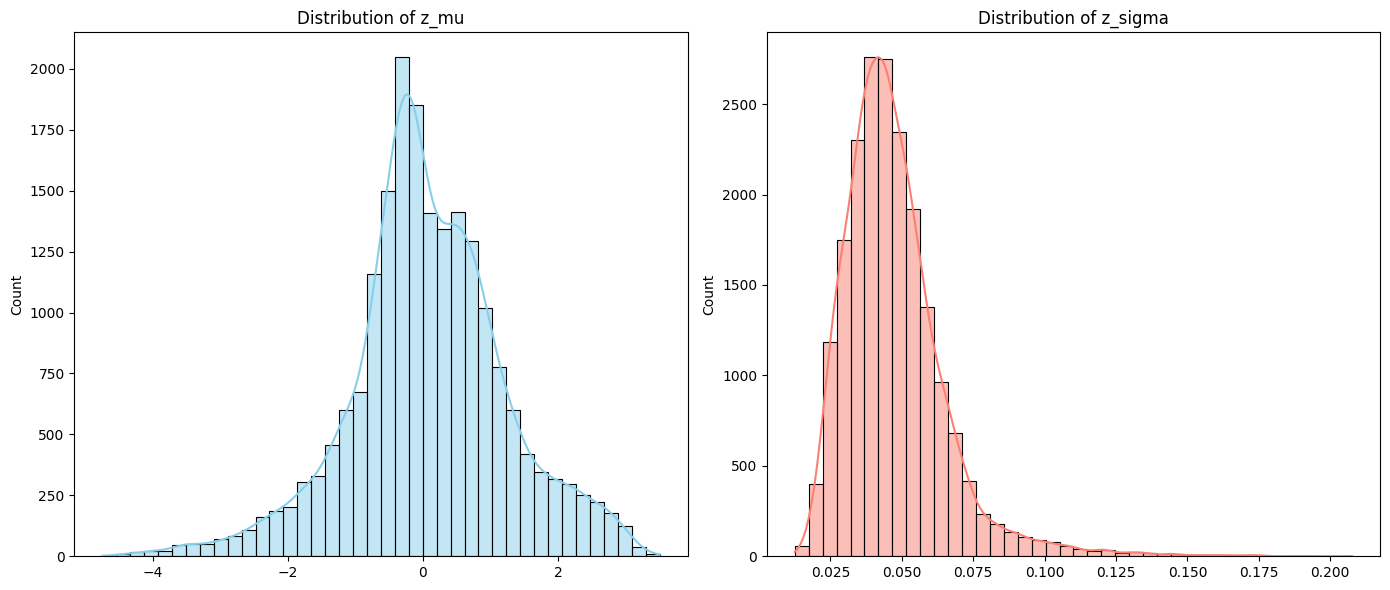

In [14]:
import seaborn as sns
import pandas as pd

# Step 1: Create a new model that outputs z_mu and z_log_sigma
encoder_stats = Model(input_img, [z_mu, z_log_sigma])

# Step 2: Get outputs for validation data
z_mu_vals, z_log_sigma_vals = encoder_stats.predict(X_valid, batch_size=batch_size)

# Step 3: Compute statistics
z_sigma_vals = np.exp(z_log_sigma_vals)  # convert log sigma to sigma

# Flatten for global stats
z_mu_flat = z_mu_vals.flatten()
z_sigma_flat = z_sigma_vals.flatten()

print("\n Latent Space Statistics")
print(f"Mean of z_mu         : {np.mean(z_mu_flat):.4f}")
print(f"Std. Dev of z_mu     : {np.std(z_mu_flat):.4f}")
print(f"Mean of z_sigma      : {np.mean(z_sigma_flat):.4f}")
print(f"Std. Dev of z_sigma  : {np.std(z_sigma_flat):.4f}")

# Step 4: Visualize with histograms
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(z_mu_flat, bins=40, kde=True, color='skyblue')
plt.title('Distribution of z_mu')

plt.subplot(1, 2, 2)
sns.histplot(z_sigma_flat, bins=40, kde=True, color='salmon')
plt.title('Distribution of z_sigma')

plt.tight_layout()
plt.show()
